## Digital Signal Processing - Session 4

### 1. Electrocardiogram (ECG) Data Loading and Basic Properties

Here, we load the `electrocardiogram` dataset from `scipy.datasets`. The `ecg` variable will hold the signal data.

In [2]:
from scipy.datasets import electrocardiogram
ecg = electrocardiogram()
ecg

array([-0.245, -0.215, -0.185, ..., -0.405, -0.395, -0.385],
      shape=(108000,))

First, we load a sample electrocardiogram (ECG) signal from `scipy.datasets` and inspect its properties. The `electrocardiogram()` function returns a 1D NumPy array representing the ECG signal.

In [3]:
type(ecg)

numpy.ndarray

We check the data type of the loaded `ecg` signal, which is typically a NumPy array.

In [4]:
ecg.shape, ecg.mean(), ecg.std()

((108000,), np.float64(-0.16510875), np.float64(0.5992473991177295))

This cell calculates and displays the `shape` (dimensions), `mean` (average value), and `std` (standard deviation) of the ECG signal. These are fundamental statistical properties.

In [5]:
ecg.size

108000

We check the total number of samples (elements) in the `ecg` array using `.size`.

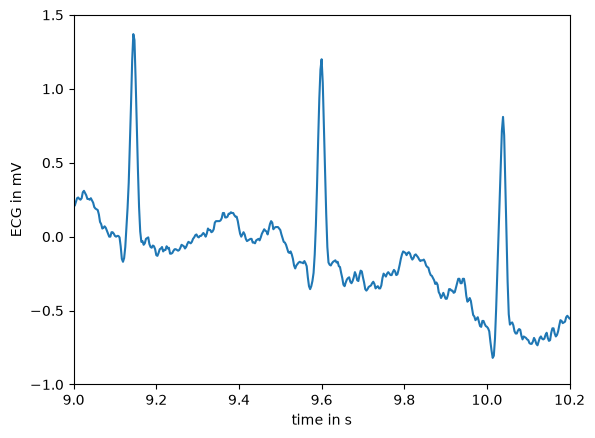

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fs = 360
time = np.arange(ecg.size) / fs
plt.plot(time, ecg)
plt.xlabel("time in s")
plt.ylabel("ECG in mV")
plt.xlim(9, 10.2)
plt.ylim(-1, 1.5)
plt.show()

This code block imports `numpy` for numerical operations and `matplotlib.pyplot` for plotting. It then calculates a time vector based on the sampling frequency (`fs = 360 Hz`) and plots a specific segment of the ECG signal (from 9 to 10.2 seconds).

### 2. Visualizing the ECG Signal

We use `matplotlib` to plot sections of the ECG signal over time. The `fs` (sampling frequency) is used to convert sample indices to time in seconds.

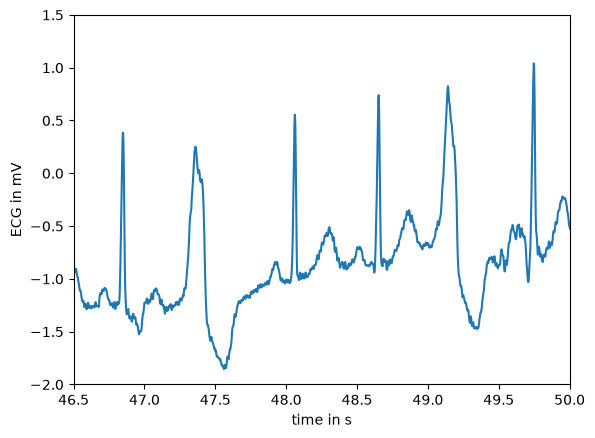

In [7]:
plt.plot(time, ecg)
plt.xlabel("time in s")
plt.ylabel("ECG in mV")
plt.xlim(46.5, 50)
plt.ylim(-2, 1.5)
plt.show()

This plot shows another segment of the ECG signal, from 46.5 to 50 seconds, allowing for examination of different parts of the waveform.

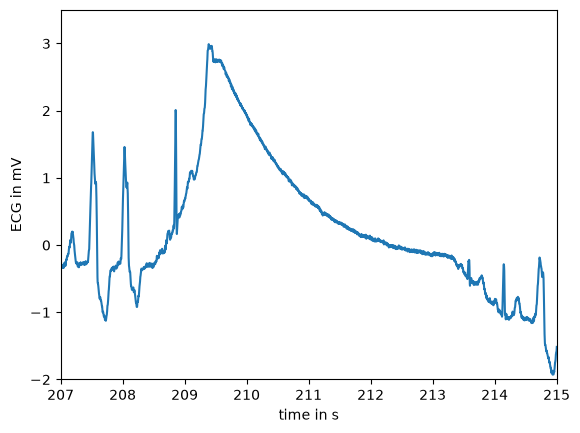

In [8]:
plt.plot(time, ecg)
plt.xlabel("time in s")
plt.ylabel("ECG in mV")
plt.xlim(207, 215)
plt.ylim(-2, 3.5)
plt.show()

This plot visualizes a segment of the ECG signal from 207 to 215 seconds, with an adjusted y-axis range to better display the amplitude variations in this section.

In [9]:
import sounddevice
from scipy.io.wavfile import write
fs= 44100
second = int(input("enter time duration in second:"))
print("recording...")
record_voice= sounddevice.rec(int(second * fs), samplerate=fs, channels=1)
sounddevice.wait()
write("output.wav", fs, record_voice)
print("recording complete")

recording...
recording complete


This cell uses the `sounddevice` library to record audio. It prompts the user for a duration in seconds, records audio at a sampling rate of `44100 Hz`, and saves it as `output.wav` using `scipy.io.wavfile.write`.

### 3. Audio Recording and Playback

This section demonstrates how to record audio from the microphone and play it back using the `sounddevice` and `soundfile` libraries.

In [10]:
sounddevice.query_devices()

   0 HDA Intel PCH: ALC3204 Analog (hw:0,0), ALSA (2 in, 0 out)
   1 HDA Intel PCH: HDMI 0 (hw:0,3), ALSA (0 in, 8 out)
   2 HDA Intel PCH: HDMI 1 (hw:0,7), ALSA (0 in, 8 out)
   3 HDA Intel PCH: HDMI 2 (hw:0,8), ALSA (0 in, 8 out)
   4 sysdefault, ALSA (128 in, 0 out)
   5 hdmi, ALSA (0 in, 8 out)
   6 pipewire, ALSA (128 in, 128 out)
*  7 default, ALSA (128 in, 128 out)
   8 Default Sink, PulseAudio (0 in, 32 out)
   9 Default Source, PulseAudio (32 in, 0 out)
  10 alsa_output.pci-0000_00_1f.3.analog-stereo, PulseAudio (0 in, 2 out)
  11 alsa_output.pci-0000_00_1f.3.analog-stereo.monitor, PulseAudio (2 in, 0 out)
  12 alsa_input.pci-0000_00_1f.3.analog-stereo, PulseAudio (2 in, 0 out)

This command queries and lists the available audio devices on the system, which can be useful for debugging or selecting specific input/output devices.

In [11]:
import sounddevice as sd
import soundfile as sf

filename = 'output.wav'

data,fs = sf.read(filename, dtype='float32')
sd.play(data, fs)
status = sd.wait()

This code reads the recorded `output.wav` file using `soundfile` and then plays it back using `sounddevice.play()`. The `status = sd.wait()` ensures the script waits until playback is complete.

In [12]:
from IPython.display import Audio
Audio(data, rate=fs, autoplay=True)

This cell provides an alternative way to play the audio directly within the Jupyter/Colab environment using `IPython.display.Audio`, which embeds an audio player.

In [13]:
type(data)

numpy.ndarray

We check the data type of the audio data loaded from the `.wav` file.

In [14]:
data.shape

(220500,)

This displays the `shape` of the audio data array, indicating its dimensions (e.g., number of samples).

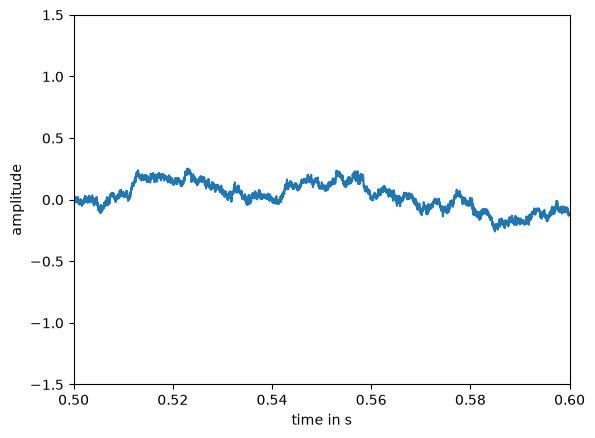

In [15]:
fs = 44100
time = np.arange(data.size) / fs
plt.plot(time, data)
plt.xlabel("time in s")
plt.ylabel("amplitude")
plt.xlim(0.5, 0.6)
plt.ylim(-1.5, 1.5)
plt.show()

This cell plots a small segment of the recorded audio signal over time, similar to the ECG plotting. It helps visualize the waveform of the recorded sound.

In [16]:
import numpy as np
import cmath
import math
import matplotlib.pyplot as plt

We import the necessary libraries: `numpy` for numerical operations, `cmath` for complex math functions, `math` for standard math functions, and `matplotlib.pyplot` for plotting.

### 4. Complex Numbers in Python

This section introduces complex number operations and their visualization using `numpy`, `cmath`, and `matplotlib`.

In [17]:
cmath.sqrt(-1)

1j

This demonstrates the use of `cmath.sqrt()` to calculate the square root of a negative number, resulting in a complex number.

In [18]:
z = 2 + 3j
print(z)

(2+3j)


A complex number `z` is defined and printed. In Python, `j` is used to denote the imaginary unit.

In [19]:
print(np.real(z))
print(np.imag(z))
print(np.abs(z))
print(np.angle(z))

2.0
3.0
3.6055512754639896
0.982793723247329


This cell extracts and prints the `real` part, `imaginary` part, `magnitude` (absolute value), and `angle` (phase) of the complex number `z` using `numpy` functions.

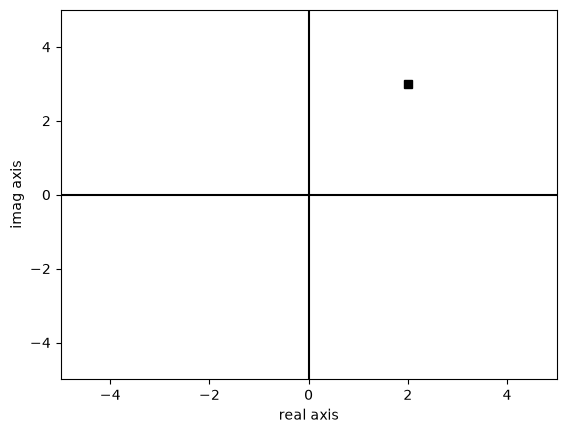

In [20]:
# plot the complex number
plt.plot(np.real(z),np.imag(z), 'ks')

# make plot look nicer
plt.xlim([-5,5])
plt.ylim([-5,5])
plt.plot([-5,5], [0,0],'k')
plt.plot([0,0], [-5,5],'k')
plt.xlabel('real axis')
plt.ylabel('imag axis')
plt.show()

This code plots the complex number `z` on a Cartesian (real-imaginary) plane. The `plt.plot` function plots the point, and `plt.xlim`, `plt.ylim`, `plt.plot([lines])` are used to set up the axes and make the plot visually appealing.

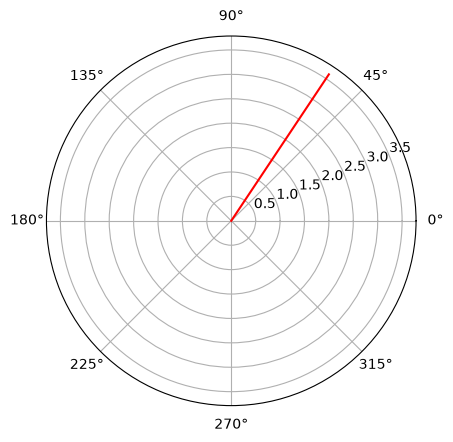

In [21]:
mag = np.abs(z)
ang = np.angle(z)

plt.polar([0, ang], [0, mag], 'r')
plt.show()

This cell visualizes the complex number `z` in polar coordinates. `plt.polar()` is used to draw a line from the origin to the point defined by its angle (`ang`) and magnitude (`mag`).

In [22]:
p = [1, 0, 0, 1]
np.roots(p)

array([-1. +0.j       ,  0.5+0.8660254j,  0.5-0.8660254j])

This cell finds the roots of the polynomial defined by the coefficients `p = [1, 0, 0, 1]`, which represents the polynomial $x^3 + 1 = 0$. `np.roots()` returns the roots, which can be real or complex.